 **Sentiment Ananlysis using machine Learning (NLP)**
  
  *This project classifies movie reviews as  **Positive** or **Negative** using Natural lanuage processing and Machine learning techniques*


In [53]:
#importing required libraries as needed for the project
import pandas as pd


**STEP-1 Load Dataset**

In [54]:
#loading dataset
data=pd.read_csv("IMDB_dataset.csv")

In [55]:
#Display first few rows
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**STEP 2- Explore Dataset**

we check structure ,missing value, and sample resources

In [56]:
#Checking dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [57]:
#checking missing value
data.isnull().sum()

,0
review,0
sentiment,0


In [58]:
data['sentiment'].value_counts() #check data (column'sentiment') .value_counts() #(counts how mny times a value appear)

,count
sentiment,
positive,25000
negative,25000


STEP 3- Text Preprocessing

We prepare  the text data by removing stopwords ,coverting text  to lower caseand cleaning unecessary words

In [59]:
import nltk #loads nlp library (natural language toolkit)

In [60]:
from nltk.corpus import stopwords #gives common words like : is,the,and

In [62]:
from nltk.tokenize import word_tokenize  # used to split sentence into words ('there'  'is' 'cat')

In [63]:
nltk.download('punkt_tab') #manully downnlloaded it

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [80]:
nltk.download('stopwords') #downloads list of stopwords
nltk.download('punkt') #needed for tokenization (splitting words) without this code will give error

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [65]:
stop_words=set(stopwords.words('english'))#get english stopwords #set bcz of duplication

**CLEANING TEXT** (Tokenization ,lowercase,remove symbol)





In [81]:
#cleaning text data
data['review']= data['review'].apply(lambda x: ' '.join(word.lower()for word in word_tokenize(x) if word.isalpha()))

In [ ]:
#data['review'].apply(....) means apply fucntion to every review
#lambda x: x=one review(one sentence) example "this movie is gd !"
#words_tokenize(x) split into words ('This'  'movie'  'is' 'gd' '!')
# if word.isalpha() : keep only alpha remove(!@#special char,numbers)
#word.lower() convert to lower case (this)
#''.join(...) join the words back

**REMOVE STOPWORDS**

In [ ]:
#removing stopwords using stopwords list
data['review']= data['review'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))

In [ ]:
#x.split it split the sentence into word
# if word not in stop_words removes stopwords

In [ ]:
#previewing cleaned data
print(data['review'].head())

**STEP 4- Text vectorization**

We convert the cleaned text data into numerical format using TF-IDF

In [ ]:
#importing TF-IDF vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer()

In [ ]:
#applying vectorization
x=vectorizer.fit_transform(data['review'])
#Target variable
y= data['sentiment']

**STEP 5- Train-Test Split**

we split the dataset into training and testing sets

In [ ]:
#Importing train-test split
from sklearn.model_selection import train_test_split

In [ ]:
#Splitting dataset into 80% training and 20% testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

**STEP 6- Model Training**

We train a naive Bayes  model on the Training data
naive bayes is commonly used for text classification tasks due to its efficiency and good performance on textual data

In [ ]:
#Importing naive bayes model
from sklearn.naive_bayes import MultinomialNB


In [ ]:
#Intializing
model=MultinomialNB()


In [ ]:
#Traing the model
model.fit(x_train,y_train)

**STEP 7- Prediction**

We use the training model to predict sentiment on the test data.

In [82]:
#Making prediction on test data
y_pred = model.predict(x_test)

**STEP 8-Model Evalution**

We evalute the model using accuracy precision ,recall ,and F1 score to measure its performance.

In [83]:
#Imporitng evalution metrics
from sklearn.metrics import accuracy_score,classification_report

In [84]:
#Calculating accuracy
print("Accuracy:",accuracy_score(y_test,y_pred))
#Detailed performance report
print(classification_report(y_test,y_pred))

Accuracy: 0.8672
              precision    recall  f1-score   support

    negative       0.86      0.88      0.87      4961
    positive       0.88      0.85      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



**STEP 9-Confusion Matrix**

We visualize the performance of the model using confusion matrix to understand correct and incorrect prediction.

In [85]:
#Importing  confusion matrix tool
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [86]:
#Creating confusion matrix
cm= confusion_matrix(y_test,y_pred)

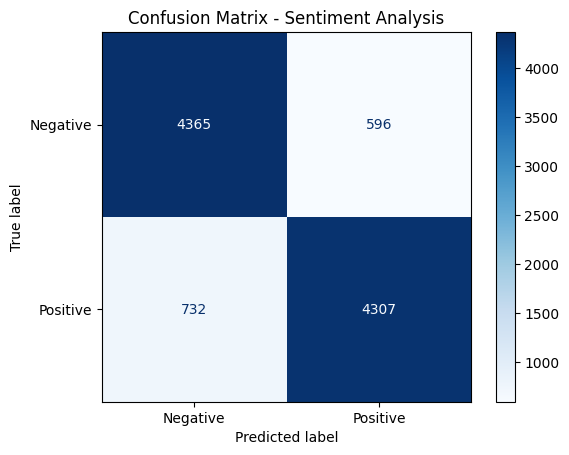

In [87]:
#Displaying confusion Matrix
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Negative","Positive"])
disp.plot(cmap="Blues")
#Adding title
plt.title("Confusion Matrix - Sentiment Analysis")
#Showing plot
plt.show()

**STEP 10- Testing on Custom Input **


We test the model on new user input to see now it performs on real-world data

In [90]:
#Testing with custom input
review=["This movie was Fantastic and Enjoyable "]

#Transforming input and predicting
prediction=model.predict(vectorizer.transform(review))
print("Predicted Sentiment:",prediction)

Predicted Sentiment: ['positive']


**STEP 11- CONCLUSION**


***We Sucessfully built a sentiment analysis model using TF-IDF and Naive Bayes.
The model can classify movie reviews as positive or negative effectively***